# Notebook 02 — Baseline CNN Training

**Project:** Image-Based Fruit Ripeness Classification  
**Student:** Corneliu Rosca | STU141830  
**Week:** 3

---

## Objective

Train the custom Baseline CNN from scratch on the 9-class fruit ripeness dataset (450 images total, 50 per class). This notebook:

1. Loads the data pipeline
2. Builds the Baseline CNN architecture
3. Trains the model with EarlyStopping and ModelCheckpoint
4. Saves the best model to `saved_models/baseline_best.h5`
5. Plots and saves training curves
6. Reports best epoch validation metrics

## Expected Behaviour

With only ~35 training images per class, the baseline CNN trained from scratch will likely overfit to some degree. This is **expected** and motivates the transfer learning approach in Weeks 5–6. The baseline serves as a performance reference point.

## 1. Setup — imports and seeds

In [62]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Add project root to path
sys.path.insert(0, str(Path(os.getcwd()).parent))

import tensorflow as tf
from src.utils import set_seeds, CLASS_NAMES, NUM_CLASSES, ensure_dirs
from src.models import build_baseline_cnn
from src.data_pipeline import build_datasets

set_seeds(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available     : {len(tf.config.list_physical_devices("GPU")) > 0}')

[utils] Seeds fixed to 42
TensorFlow version: 2.11.0
GPU available     : False


## 2. Hyperparameters

In [63]:
CONFIG = {
    'data_dir':       '../dataset',
    'batch_size':     32,
    'epochs':         50,
    'learning_rate':  1e-3,
    'dropout_rate':   0.4,
    'l2_reg':         1e-4,
    'seed':           42,
    'patience':       5,
    'model_save_path': '../saved_models/baseline_best.h5',
}

for k, v in CONFIG.items():
    print(f'  {k:<18}: {v}')

ensure_dirs('../saved_models', '../results')

  data_dir          : ../dataset
  batch_size        : 32
  epochs            : 50
  learning_rate     : 0.001
  dropout_rate      : 0.4
  l2_reg            : 0.0001
  seed              : 42
  patience          : 5
  model_save_path   : ../saved_models/baseline_best.h5


## 3. Build datasets

In [64]:
train_ds, val_ds, test_ds = build_datasets(
    data_dir=CONFIG['data_dir'],
    batch_size=CONFIG['batch_size'],
    seed=CONFIG['seed']
)

# Confirm shapes
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    for images, labels in ds.take(1):
        print(f'  {name:<6}: images {images.shape}  labels {labels.shape}')

2026-05-24 13:09:05 [INFO] data_pipeline: Building datasets from: ../dataset
2026-05-24 13:09:05 [INFO] data_pipeline:   apple_unripe          :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   apple_ripe            :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   apple_overripe        :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   banana_unripe         :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   banana_ripe           :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   banana_overripe       :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   pear_unripe           :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   pear_ripe             :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_pipeline:   pear_overripe         :  35 train |   7 val |   8 test
2026-05-24 13:09:05 [INFO] data_

[utils] Seeds fixed to 42
  train : images (32, 224, 224, 3)  labels (32, 9)
  val   : images (32, 224, 224, 3)  labels (32, 9)
  test  : images (32, 224, 224, 3)  labels (32, 9)


## 4. Build Baseline CNN model

In [65]:
model = build_baseline_cnn(
    dropout_rate=CONFIG['dropout_rate'],
    l2_reg=CONFIG['l2_reg'],
    learning_rate=CONFIG['learning_rate'],
    save_summary=False
)

model.summary()

Model: "BaselineCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 224, 224, 32)      896       
                                                                 
 bn1 (BatchNormalization)    (None, 224, 224, 32)      128       
                                                                 
 relu1 (Activation)          (None, 224, 224, 32)      0         
                                                                 
 pool1 (MaxPooling2D)        (None, 112, 112, 32)      0         
                                                                 
 conv2 (Conv2D)              (None, 112, 112, 64)      18496     
                                                                 
 bn2 (BatchNormalization)    (None, 112, 112, 64)      

## 5. Configure callbacks

- **ModelCheckpoint**: saves only the model state with the lowest validation loss.
- **EarlyStopping**: stops training if val_loss does not improve for 5 consecutive epochs, then restores the best weights.
- **ReduceLROnPlateau**: halves the learning rate after 3 epochs without val_loss improvement.

In [66]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CONFIG['model_save_path'],
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['patience'],
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
]

## 6. Train the model

This is the longest cell. Expected duration:
- **CPU only**: ~30–60 seconds per epoch (50 epochs max = 25–50 min, but EarlyStopping usually triggers earlier)
- **GPU**: ~2–5 seconds per epoch (under 5 minutes total)

In [67]:
start = datetime.now()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
    verbose=1
)

elapsed = datetime.now() - start
print(f'\nTraining completed in {elapsed}')

Epoch 1/50
10/10 [==============================] - ETA: 0s - loss: 2.2094 - accuracy: 0.1714
Epoch 1: val_loss improved from inf to 2.24660, saving model to ../saved_models\baseline_best.h5
10/10 [==============================] - 11s 931ms/step - loss: 2.2094 - accuracy: 0.1714 - val_loss: 2.2466 - val_accuracy: 0.1111 - lr: 0.0010
Epoch 2/50
10/10 [==============================] - ETA: 0s - loss: 1.8935 - accuracy: 0.3270
Epoch 2: val_loss did not improve from 2.24660
10/10 [==============================] - 9s 873ms/step - loss: 1.8935 - accuracy: 0.3270 - val_loss: 2.2492 - val_accuracy: 0.1111 - lr: 0.0010
Epoch 3/50
10/10 [==============================] - ETA: 0s - loss: 1.7057 - accuracy: 0.4254
Epoch 3: val_loss improved from 2.24660 to 2.24138, saving model to ../saved_models\baseline_best.h5
10/10 [==============================] - 9s 872ms/step - loss: 1.7057 - accuracy: 0.4254 - val_loss: 2.2414 - val_accuracy: 0.1270 - lr: 0.0010
Epoch 4/50
10/10 [======================

## 7. Training curves

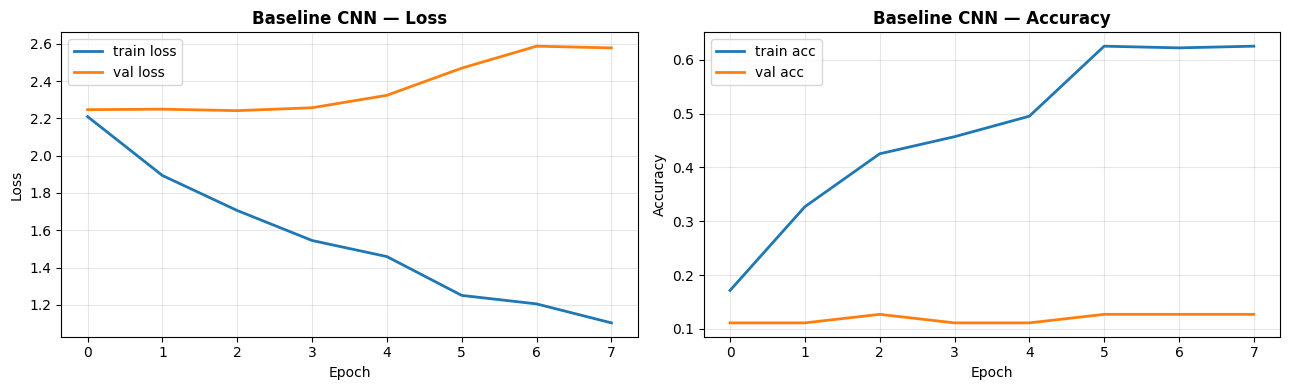

Saved → results/training_curves_baseline.png


In [72]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(hist['loss'],     label='train loss', linewidth=2)
axes[0].plot(hist['val_loss'], label='val loss',   linewidth=2)
axes[0].set_title('Baseline CNN — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(hist['accuracy'],     label='train acc', linewidth=2)
axes[1].plot(hist['val_accuracy'], label='val acc',   linewidth=2)
axes[1].set_title('Baseline CNN — Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_curves_baseline.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → results/training_curves_baseline.png')

## 8. Best epoch summary

In [73]:
best_epoch    = int(np.argmin(hist['val_loss']))
best_val_loss = hist['val_loss'][best_epoch]
best_val_acc  = hist['val_accuracy'][best_epoch]
train_acc     = hist['accuracy'][best_epoch]

print('=' * 50)
print(f'  BASELINE CNN — TRAINING SUMMARY')
print('=' * 50)
print(f'  Total epochs run        : {len(hist["loss"])}')
print(f'  Best epoch              : {best_epoch + 1}')
print(f'  Best validation loss    : {best_val_loss:.4f}')
print(f'  Best validation accuracy: {best_val_acc:.4f}')
print(f'  Training accuracy (same epoch): {train_acc:.4f}')
print(f'  Overfit gap (train - val): {(train_acc - best_val_acc):.4f}')
print('=' * 50)
print(f'  Model saved to: {CONFIG["model_save_path"]}')

  BASELINE CNN — TRAINING SUMMARY
  Total epochs run        : 8
  Best epoch              : 3
  Best validation loss    : 2.2414
  Best validation accuracy: 0.1270
  Training accuracy (same epoch): 0.4254
  Overfit gap (train - val): 0.2984
  Model saved to: ../saved_models/baseline_best.h5


## 9. Save training history

In [74]:
df = pd.DataFrame(hist)
df.index.name = 'epoch'
df.to_csv('../results/history_baseline.csv')
print('Saved → results/history_baseline.csv')
df.tail()

Saved → results/history_baseline.csv


,loss,accuracy,val_loss,val_accuracy,lr
epoch,,,,,
3,1.544918,0.457143,2.256840,0.111111,0.0010
4,1.458653,0.495238,2.323679,0.111111,0.0010
5,1.250423,0.625397,2.469350,0.126984,0.0010
6,1.204914,0.622222,2.587179,0.126984,0.0005
7,1.103038,0.625397,2.577840,0.126984,0.0005


## 10. Update results.csv

In [71]:
results_path = Path('../results/results.csv')

new_row = {
    'model':            'baseline',
    'epoch':            best_epoch + 1,
    'val_loss':         round(best_val_loss, 4),
    'val_acc':          round(best_val_acc, 4),
    'precision_macro':  'N/A',
    'recall_macro':     'N/A',
    'f1_macro':         'N/A',
}

if results_path.exists():
    existing = pd.read_csv(results_path)
    existing = existing[existing['model'] != 'baseline']
    df_out = pd.concat([existing, pd.DataFrame([new_row])], ignore_index=True)
else:
    df_out = pd.DataFrame([new_row])

df_out.to_csv(results_path, index=False)
print('Updated → results/results.csv')
df_out

Updated → results/results.csv


,model,epoch,val_loss,val_acc,precision_macro,recall_macro,f1_macro
0,baseline,3,2.2414,0.127,N/A,N/A,N/A


## 11. Summary and next steps

**Completed in this notebook:**

| Step | Status |
|------|--------|
| Baseline CNN architecture built | ✅ |
| Trained with EarlyStopping + ReduceLROnPlateau | ✅ |
| Best model saved to `saved_models/baseline_best.h5` | ✅ |
| Training curves saved to `results/training_curves_baseline.png` | ✅ |
| Training history saved to `results/history_baseline.csv` | ✅ |
| Validation metrics added to `results/results.csv` | ✅ |

**Next step:** Week 4 — full evaluation of the baseline on the test set, producing per-class metrics, confusion matrix, and ROC curves (notebook `03_evaluation_baseline.ipynb` or via `python src/evaluate.py --model_path saved_models/baseline_best.h5`).